已知cold matter 密度场功率谱

$$
P_{\mathrm{CMD}}(k) = A_{s}k ^{n_{s} }T ^{2 }(k)\,,
$$

其中 $A_{s}$ 为归一化系数，通过观测数据确定。$n_{s}=0.96$ 为谱指数，$T(k)$ 是 transfer function，从给定的表格插值得到。


平滑尺度 $R$ 的密度起伏的 variance 为

$$
\sigma ^{2 }(R) = \int_{0}^{\infty } \frac{4\pi k^{2 }}{(2\pi)^{3 }} P_{\mathrm{CDM}} (k)W^{2 }(k,R)\mathrm{d}k\,,\tag{$2$}
$$

其中窗函数

$$
W(k,R) = \frac{3 \left[ \sin(kR) - (kR)\cos(kR) \right]   }{(kR)^{3 }}\,,
$$

为实空间中半径为 $R$ 的 top-hat 函数在傅里叶空间的形式。记 $\sigma(R=8h^{-1 }\mathrm{Mpc})=\sigma_{8}$ ，观测表明 $\sigma_{8}=0.82$ 。

先设 $A_{s}=1$ ，取 $R=8h^{-1 }\mathrm{Mpc},h=0.6774$ ，从Eq . (2) 中计算出 $\sigma ^{2 }(R=8h ^{-1 }\mathrm{Mpc})$ ，然后用观测值 $(0.82)^{2 }$ 除以这个结果，得到归一化系数 $A_{s}$ ，再将 $P_{\mathrm{CDM}}(k)$ 作为 $k$ 的函数画出来，$k\in (10^{-5 },10^{3 })\mathrm{Mpc}^{-1 }$ . 


In [1]:
import numpy as np
from scipy.interpolate import interp1d

data = np.loadtxt('./transfer-function.txt',skiprows=1)
data_lgk = np.log10(data[:,0])
data_lgTk = np.log10(data[:,1])

print('data_lgk:', data_lgk[0:5])
print('data_lgTk:', data_lgTk[0:5])

data_lgk: [-6.    -5.988 -5.976 -5.964 -5.952]
data_lgTk: [0. 0. 0. 0. 0.]


In [2]:
lgTk_interp = interp1d(data_lgk, data_lgTk, kind='cubic')

def Tk(k):
    lgk = np.log10(k)
    lgTk = lgTk_interp(lgk)
    return 10**lgTk

In [3]:
k = 1e2
print(f'Tk(k={k}): {Tk(k)}')

Tk(k=100.0): 6.466406067701704e-07


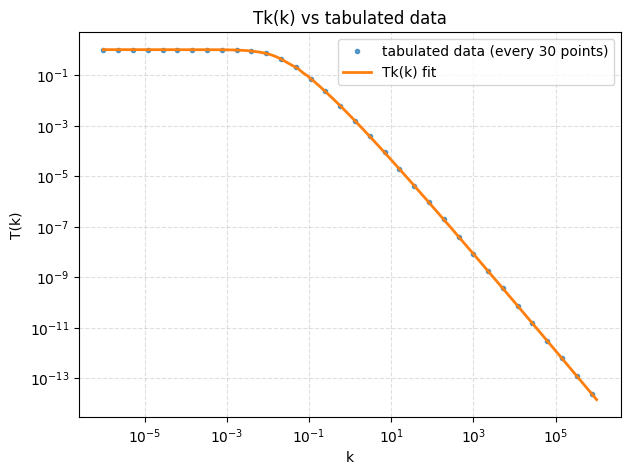

In [4]:
import matplotlib.pyplot as plt

k_values = np.logspace(np.log10(data[:, 0].min()), np.log10(data[:, 0].max()), 400)
Tk_values = Tk(k_values)

plt.figure(figsize=(7, 5))
plt.loglog(data[::30, 0], data[::30, 1], 'o', ms=3, alpha=0.7, label='tabulated data (every 30 points)')
plt.loglog(k_values, Tk_values, '-', lw=2, label='Tk(k) fit')
plt.xlabel('k')
plt.ylabel('T(k)')
plt.title('Tk(k) vs tabulated data')
plt.grid(True, which='both', ls='--', alpha=0.4)
plt.legend()
plt.show()

$$
P_{\mathrm{CMD}}(k) = A_{s}k ^{n_{s} }T ^{2 }(k)\,.
$$

$$
W(k,R) = \frac{3 \left[ \sin(kR) - (kR)\cos(kR) \right]   }{(kR)^{3 }}\,.
$$

In [5]:
def P_cdm_0(k):
    A = 1.0
    n_s = 0.96
    return A * k**n_s * Tk(k)**2

def Windows(k,R):
    x = k * R
    return 3 * (np.sin(x) - x * np.cos(x)) / x**3

$$
\sigma ^{2 }(R) = \int_{0}^{\infty } \frac{4\pi k^{2 }}{(2\pi)^{3 }} P_{\mathrm{CDM}} (k)W^{2 }(k,R)\mathrm{d}k\,,\tag{$2$}\,. 
$$

In [6]:
def sigma_R(R):
    k_min = 1e-5
    k_max = 1e5

    x = np.linspace(np.log(k_min), np.log(k_max), 2000)
    k = np.exp(x)

    integrand = k**3 * P_cdm_0(k) * Windows(k, R)**2
    sigma2 = np.trapezoid(integrand, x) / (2 * np.pi**2)

    return np.sqrt(sigma2)


In [7]:

As = 0.82**2/sigma_R(8.0)
print(f'归一化常数 As: {As}')

归一化常数 As: 2420.164297558099


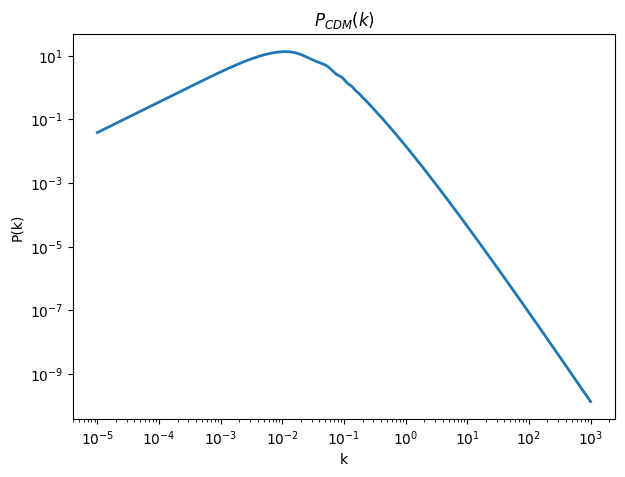

In [8]:
def P_cdm(k):
    n_s = 0.96
    return As * k**n_s * Tk(k)**2

k_values = np.logspace(-5, 3, 400)
P_CDM_k_values = P_cdm(k_values)

plt.figure(figsize=(7, 5))
plt.loglog(k_values, P_CDM_k_values, '-', lw=2)
plt.xlabel('k')
plt.ylabel('P(k)')
plt.title('$P_{{CDM}}(k)$')
# plt.grid(True, which='both', ls='--', alpha=0.4)
# plt.legend()
plt.show()